# Cellular Automaton Model for Laser Dynamics

This code implements a Cellular Automaton (CA) model to simulate laser dynamics as described in:

Guisado et al., *Phys. Rev. E 67, 066708 (2003)*



## Overview

The simulation models a laser cavity as a 2D square lattice where:

- Each cell represents an atom.
- Atoms can be in:
  - Ground state (0)
  - Excited state (1)
- Photons are stored locally in each cell.
- Time evolves in discrete steps.
- All cells update synchronously.

The model reproduces laser phenomena



## Physical Parameters

- `L` → Lattice size (L × L cells)
- `t_a` → Lifetime of excited electrons (upper laser level)
- `t_c` → Photon lifetime inside cavity
- `lam` → Pumping probability per time step


## Cellular Automaton Rules

At each time step:

1. **Pumping**
   - Ground-state electrons become excited with probability λ.

2. **Stimulated Emission**
   - If an excited electron has at least one photon in its Moore neighborhood,
     it emits a photon and returns to ground state.

3. **Photon Decay**
   - Each photon disappears after t_c time steps.

4. **Electron Decay**
   - Excited electrons decay to ground state after t_a time steps.

5. **Noise Injection**
   - A small number (0.01%) of random photons are added each step to simulate noise.



## Threshold Determination

The laser threshold λ_t is determined by:

    average photon number > 1.25 × noise photon level

**Note:** I have Implemented binary search method (not mentioned in paper) for efficient computation of λ_t.



## Figures Reproduced

- Figure 2 → Threshold λ_t vs t_a and t_c
- Figure 3 → Scaling λ_t vs (t_a × t_c)
- Figure 5 → Evolution of system with different parameters
- Figure 6 → Evolution of system with different parameters
- Figure 7 →  Instantaneous transverse spatiotemporal patterns
shown by the laser photon population in the system.

Submitted by: **Amarnath (MS22070)**


Computing threshold t_a=10, t_c=3
Computing threshold t_a=20, t_c=3
Computing threshold t_a=50, t_c=3
Computing threshold t_a=100, t_c=3
Computing threshold t_a=200, t_c=3
Computing threshold t_a=10, t_c=5
Computing threshold t_a=20, t_c=5
Computing threshold t_a=50, t_c=5
Computing threshold t_a=100, t_c=5
Computing threshold t_a=200, t_c=5
Computing threshold t_a=10, t_c=10
Computing threshold t_a=20, t_c=10
Computing threshold t_a=50, t_c=10
Computing threshold t_a=100, t_c=10
Computing threshold t_a=200, t_c=10
Computing threshold t_a=10, t_c=20
Computing threshold t_a=20, t_c=20
Computing threshold t_a=50, t_c=20
Computing threshold t_a=100, t_c=20
Computing threshold t_a=200, t_c=20


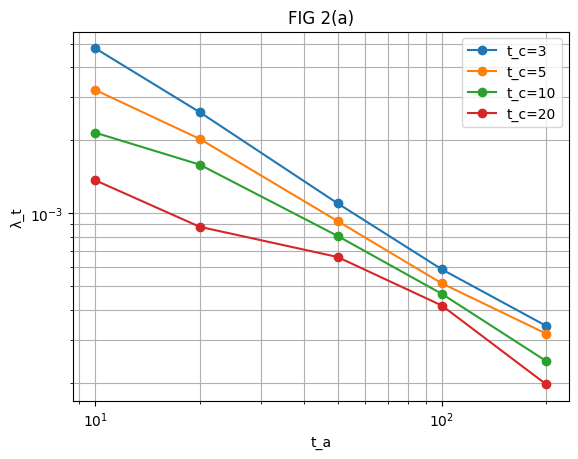

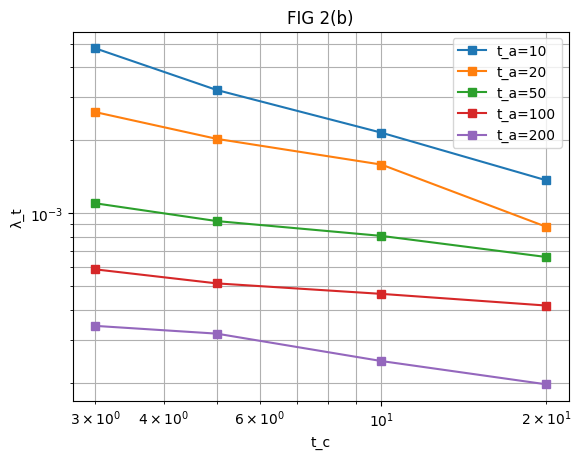

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# One Cellular automata step

def step(a, a_age, c, photon_age, L, t_a, t_c, lam, noise_cells):

    # Pumping
    pump_mask = (a == 0) & (np.random.rand(L, L) < lam)
    a[pump_mask] = 1
    a_age[pump_mask] = 0

    # Stimulated emission
    G = np.zeros((L, L))

    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            G += np.roll(np.roll(c, dx, axis=0), dy, axis=1)

    stim_mask = (a == 1) & (G >= 1)

    indices = np.argwhere(stim_mask)

    for i, j in indices:
        c[i, j] += 1
        photon_age[i][j].append(0)

    a[stim_mask] = 0
    a_age[stim_mask] = 0

    # Photon decay
    for i in range(L):
        for j in range(L):
            new_list = []
            for age in photon_age[i][j]:
                if age + 1 < t_c:
                    new_list.append(age + 1)
            photon_age[i][j] = new_list
            c[i, j] = len(new_list)

    # Electron decay
    excited = (a == 1)
    a_age[excited] += 1

    decay_mask = (a_age >= t_a)
    a[decay_mask] = 0
    a_age[decay_mask] = 0

    # Noise
    for _ in range(noise_cells):
        i = np.random.randint(L)
        j = np.random.randint(L)
        c[i, j] += 1
        photon_age[i][j].append(0)



# Run simulation (runs several cellular automata steps and averages photon count then.)


def run_simulation(L, t_a, t_c, lam, total_steps=400, transient=250):

    a = np.zeros((L, L))
    a_age = np.zeros((L, L))
    c = np.zeros((L, L))
    photon_age = [[[] for _ in range(L)] for _ in range(L)]

    Nc = L * L
    noise_cells = max(1, int(0.0001 * Nc))

    photon_record = []

    for t in range(total_steps):
        step(a, a_age, c, photon_age, L, t_a, t_c, lam, noise_cells)

        if t >= transient:
            photon_record.append(np.sum(c))

    return np.mean(photon_record)



# threshold computation 


def compute_threshold(L, t_a, t_c):

    Nc = L * L
    noise_per_step = 0.0001 * Nc
    nnp = noise_per_step * t_c
    nmin = 1.25 * nnp

    lam_low = 1e-4
    lam_high = 1e-1

    for _ in range(12):

        lam_mid = 0.5 * (lam_low + lam_high)

        avg_n = run_simulation(L, t_a, t_c, lam_mid)

        if avg_n > nmin:
            lam_high = lam_mid
        else:
            lam_low = lam_mid

    return lam_high



# Computing and storing variables


L = 150

t_a_values = np.array([10, 20, 50, 100, 200])
t_c_values = np.array([3, 5, 10, 20])

lt_matrix = np.zeros((len(t_c_values), len(t_a_values)))

for i, t_c in enumerate(t_c_values):
    for j, t_a in enumerate(t_a_values):

        print(f"Computing threshold t_a={t_a}, t_c={t_c}")

        lt = compute_threshold(L, t_a, t_c)
        lt_matrix[i, j] = lt



# Figure 2(a)


plt.figure()

for i, t_c in enumerate(t_c_values):
    plt.loglog(t_a_values,
               lt_matrix[i, :],
               marker='o',
               label=f"t_c={t_c}")

plt.xlabel("t_a")
plt.ylabel("λ_t")
plt.title("FIG 2(a)")
plt.legend()
plt.grid(True, which="both")
plt.show()



# Figure 2(b)


plt.figure()

for j, t_a in enumerate(t_a_values):
    plt.loglog(t_c_values,
               lt_matrix[:, j],
               marker='s',
               label=f"t_a={t_a}")

plt.xlabel("t_c")
plt.ylabel("λ_t")
plt.title("FIG 2(b)")
plt.legend()
plt.grid(True, which="both")
plt.show()


=
Fitted slope = -0.6411135442900857
Expected slope ≈ -1
=


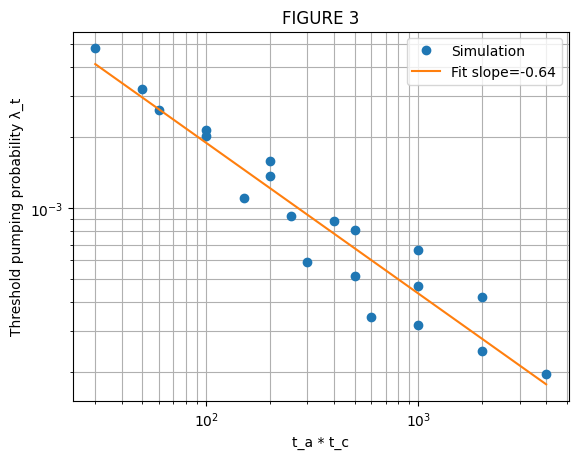

In [7]:
#For figure 3, we will plot λ_t vs t_a * t_c and perform a log-log linear fit to find the slope.
def plot_figure3():

    
    x_vals = []
    y_vals = []

    for i, t_c in enumerate(t_c_values):
        for j, t_a in enumerate(t_a_values):

            lt = lt_matrix[i, j]

            x_vals.append(t_a * t_c)
            y_vals.append(lt)

    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)

    
    # Log-log linear fit
    
    log_x = np.log10(x_vals)
    log_y = np.log10(y_vals)

    slope, intercept = np.polyfit(log_x, log_y, 1)

    print("=")
    print("Fitted slope =", slope)
    print("Expected slope ≈ -1")
    print("=")

    
    # Plot
    
    plt.figure()

    plt.loglog(x_vals, y_vals, 'o', label="Simulation")

    x_fit = np.logspace(np.log10(min(x_vals)),
                        np.log10(max(x_vals)), 200)

    y_fit = 10**intercept * x_fit**slope

    plt.loglog(x_fit, y_fit, '-', label=f"Fit slope={slope:.2f}")

    plt.xlabel("t_a * t_c")
    plt.ylabel("Threshold pumping probability λ_t")
    plt.title("FIGURE 3")
    plt.legend()
    plt.grid(True, which="both")

    plt.show()

plot_figure3()



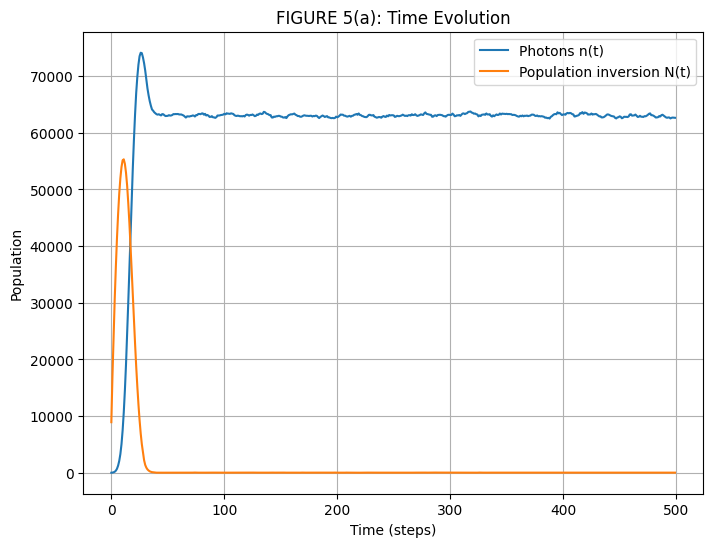

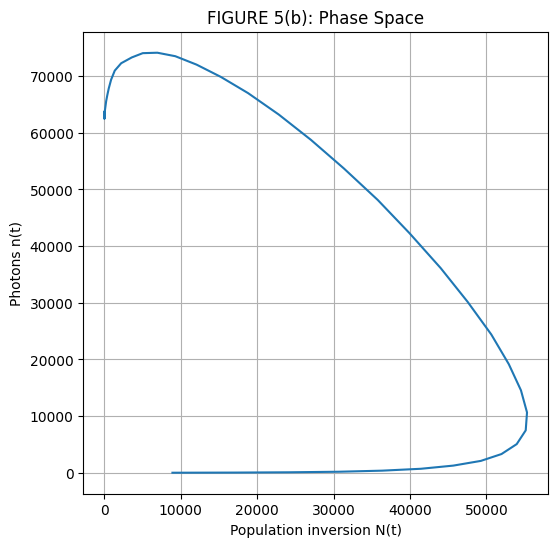

In [8]:
# Time evolution and phase space
def run_time_evolution(L, t_a, t_c, lam, total_steps=500):

    a = np.zeros((L, L), dtype=np.int8)
    a_age = np.zeros((L, L), dtype=np.int16)
    c = np.zeros((L, L), dtype=np.int16)
    photon_age = [[[] for _ in range(L)] for _ in range(L)]

    Nc = L * L
    noise_cells = max(1, int(0.0001 * Nc))

    n_t = []
    N_t = []

    for t in range(total_steps): 
        step(a, a_age, c, photon_age, L, t_a, t_c, lam, noise_cells)

        n_t.append(np.sum(c))   # total photons
        N_t.append(np.sum(a))   # population inversion

    return np.array(n_t), np.array(N_t)



# Figure 5


# Parameters from paper
L = 300
lam = 0.1
t_c = 8
t_a = 30
total_steps = 500

n_t, N_t = run_time_evolution(L, t_a, t_c, lam, total_steps)

time = np.arange(total_steps)


# (a) Time evolution
plt.figure(figsize=(8, 6))

plt.plot(time, n_t, label="Photons n(t)")
plt.plot(time, N_t, label="Population inversion N(t)")

plt.xlabel("Time (steps)")
plt.ylabel("Population")
plt.title("FIGURE 5(a): Time Evolution")
plt.legend()
plt.grid(True)

plt.show()


# (b) Phase space

plt.figure(figsize=(6, 6))

plt.plot(N_t, n_t)

plt.xlabel("Population inversion N(t)")
plt.ylabel("Photons n(t)")
plt.title("FIGURE 5(b): Phase Space")

plt.grid(True)
plt.show()


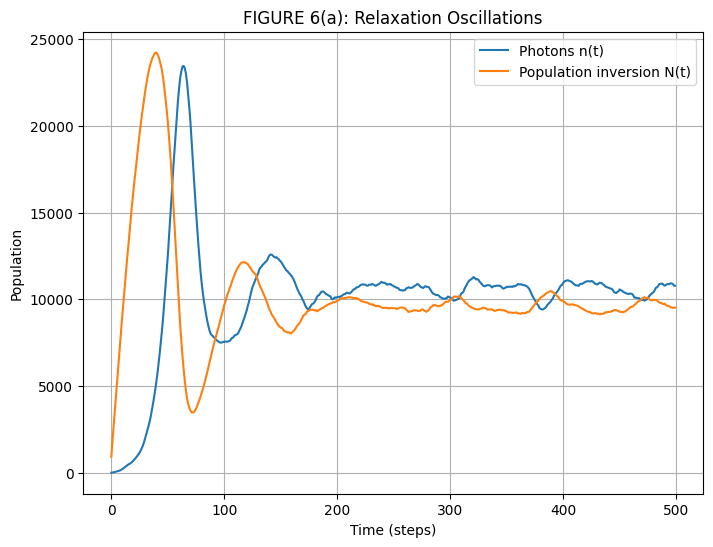

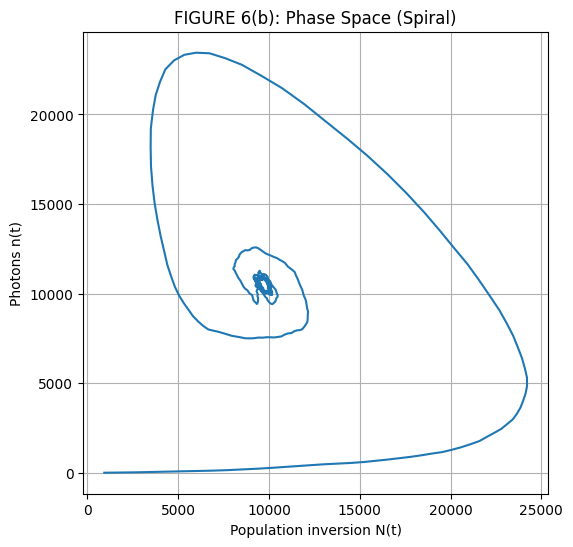

In [9]:
# Figure 6 (Oscillatory regime)


# Parameters from paper
L = 300
lam = 0.01
t_c = 14
t_a = 160
total_steps = 500


n_t, N_t = run_time_evolution(L, t_a, t_c, lam, total_steps)

time = np.arange(total_steps)


# (a) Time evolution

plt.figure(figsize=(8, 6))

plt.plot(time, n_t, label="Photons n(t)")
plt.plot(time, N_t, label="Population inversion N(t)")

plt.xlabel("Time (steps)")
plt.ylabel("Population")
plt.title("FIGURE 6(a): Relaxation Oscillations")
plt.legend()
plt.grid(True)

plt.show()


# (b) Phase space

plt.figure(figsize=(6, 6))

plt.plot(N_t, n_t)

plt.xlabel("Population inversion N(t)")
plt.ylabel("Photons n(t)")
plt.title("FIGURE 6(b): Phase Space (Spiral)")

plt.grid(True)
plt.show()


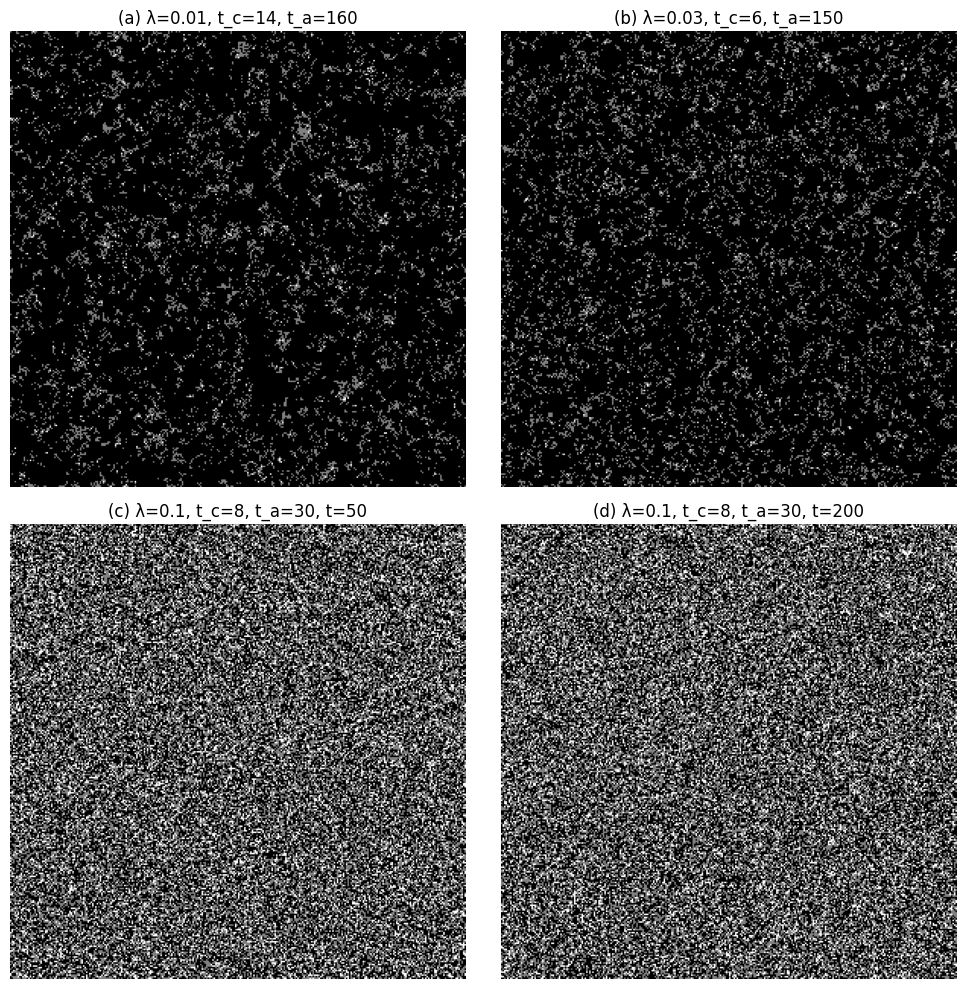

In [10]:
# Spatiotemporal patterns
def run_until(L, t_a, t_c, lam, target_time): #for getting the photon map at a specific time step

    a = np.zeros((L, L))
    a_age = np.zeros((L, L))
    c = np.zeros((L, L))
    photon_age = [[[] for _ in range(L)] for _ in range(L)]

    Nc = L * L
    noise_cells = max(1, int(0.0001 * Nc))

    for t in range(target_time):
        step(a, a_age, c, photon_age, L, t_a, t_c, lam, noise_cells)

    return c.copy()


def plot_pattern(ax, photon_map, title):

    pattern = np.zeros_like(photon_map)

    pattern[photon_map == 1] = 1
    pattern[photon_map >= 2] = 2

    ax.imshow(pattern, cmap="gray", vmin=0, vmax=2)
    ax.set_title(title)
    ax.axis("off")



# FIGURE 7 (Spatiotemporal patterns)

L = 300

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# (a) Oscillatory case
pattern_a = run_until(L, t_a=160, t_c=14, lam=0.01, target_time=400)
plot_pattern(axes[0, 0], pattern_a, "(a) λ=0.01, t_c=14, t_a=160")

# (b) Oscillatory case
pattern_b = run_until(L, t_a=150, t_c=6, lam=0.03, target_time=400)
plot_pattern(axes[0, 1], pattern_b, "(b) λ=0.03, t_c=6, t_a=150")

# (c) Non-oscillatory early time
pattern_c = run_until(L, t_a=30, t_c=8, lam=0.1, target_time=50)
plot_pattern(axes[1, 0], pattern_c, "(c) λ=0.1, t_c=8, t_a=30, t=50")

# (d) Non-oscillatory later time
pattern_d = run_until(L, t_a=30, t_c=8, lam=0.1, target_time=200)
plot_pattern(axes[1, 1], pattern_d, "(d) λ=0.1, t_c=8, t_a=30, t=200")

plt.tight_layout()
plt.show()
